# Geospatial Plume AI Model Comparison: CNN vs LSTM

This notebook loads the EDA dataset, trains CNN and LSTM models to predict next-frame plume concentration, evaluates them, and compares their performance.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
# Dataset location
DATA_DIR = Path("../EDA/data").resolve()
WINDOWS_DIR = DATA_DIR / "windows"
print("Data directory:", DATA_DIR)
print("Window files found:", len(list(WINDOWS_DIR.glob("*.npz"))))

# Sample inspection
sample_path = sorted(WINDOWS_DIR.glob("*.npz"))[0]
with np.load(sample_path, allow_pickle=True) as data:
    print("Sample file:", sample_path.name)
    print("Input shape:", data["input"].shape)
    print("Target shape:", data["target"].shape)

def extract_input(input_window: np.ndarray) -> np.ndarray:
    # Input is (3, 10, 64, 64)
    return input_window

def extract_target(target_window: np.ndarray) -> np.ndarray:
    # Target is (1, 1, 64, 64), take the plume channel
    return target_window[0, 0, :, :]

def build_dataset(paths, max_samples=None, random_seed=42):
    selected = sorted(paths)
    if max_samples is not None:
        np.random.seed(random_seed)
        selected = np.random.permutation(selected)[:max_samples]

    X = []
    y = []
    for path in selected:
        with np.load(path, allow_pickle=True) as data:
            X.append(extract_input(data["input"]))
            y.append(extract_target(data["target"]))

    return np.array(X), np.array(y)

window_paths = sorted(WINDOWS_DIR.glob("*.npz"))
X, y = build_dataset(window_paths, max_samples=1000)  # Use fewer for faster training
print("Input shape:", X.shape)
print("Target shape:", y.shape)

# Normalize inputs (simple min-max for each channel)
X_min = X.min(axis=(0,1,3,4), keepdims=True)
X_max = X.max(axis=(0,1,3,4), keepdims=True)
X_norm = (X - X_min) / (X_max - X_min + 1e-8)

# For target, normalize similarly
y_min = y.min()
y_max = y.max()
y_norm = (y - y_min) / (y_max - y_min + 1e-8)

# Reshape target to add channel dimension: (batch, 64, 64) -> (batch, 64, 64, 1)
y_norm = y_norm.reshape(y_norm.shape[0], 64, 64, 1)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=0.2, random_state=42)
print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

Data directory: C:\Users\joaoh\Documents\GitHub\Geospatial-Forecasting\EDA\data
Window files found: 40215
Sample file: 000003_000.npz
Input shape: (3, 10, 64, 64)
Target shape: (1, 10, 64, 64)
Input shape: (1000, 3, 10, 64, 64)
Target shape: (1000, 64, 64)
Train shapes: (800, 3, 10, 64, 64) (800, 64, 64, 1)
Test shapes: (200, 3, 10, 64, 64) (200, 64, 64, 1)


In [3]:
def build_cnn_model(input_shape=(64, 64, 30)):
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        keras.layers.UpSampling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        keras.layers.UpSampling2D((2, 2)),
        keras.layers.Conv2D(1, (3, 3), activation='linear', padding='same')
    ])
    return model

# Reshape X for CNN: (batch, 3, 10, 64, 64) -> (batch, 64, 64, 30)
X_train_cnn = X_train.reshape(X_train.shape[0], 3*10, 64, 64).transpose(0, 2, 3, 1)
X_test_cnn = X_test.reshape(X_test.shape[0], 3*10, 64, 64).transpose(0, 2, 3, 1)

cnn_model = build_cnn_model()
cnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         8,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,393 (685.13 KB)

 Trainable params: 175,393 (685.13 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
def build_lstm_model(input_shape=(3, 64, 64, 10)):
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        keras.layers.ConvLSTM2D(32, (3, 3), padding='same', return_sequences=True),
        keras.layers.ConvLSTM2D(64, (3, 3), padding='same', return_sequences=False),
        keras.layers.Conv2D(1, (3, 3), activation='linear', padding='same')
    ])
    return model

lstm_model = build_lstm_model()
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 3, 64, 64, 32)  │        48,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 64, 64, 64)     │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270,529 (1.03 MB)

 Trainable params: 270,529 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Reshape X for LSTM: (batch, 3, 10, 64, 64) -> (batch, 3, 64, 64, 10)
X_train_lstm = X_train.transpose(0, 1, 3, 4, 2)
X_test_lstm = X_test.transpose(0, 1, 3, 4, 2)

# Use MAE loss instead of MSE for better performance with sparse data
# and train longer with callbacks to monitor overfitting
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train CNN with more epochs
history_cnn = cnn_model.fit(
    X_train_cnn, y_train, 
    epochs=30, 
    batch_size=16, 
    validation_split=0.2, 
    verbose=1,
    callbacks=[early_stop]
)

# Train LSTM with more epochs
history_lstm = lstm_model.fit(
    X_train_lstm, y_train, 
    epochs=30, 
    batch_size=16, 
    validation_split=0.2, 
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.0130 - mae: 0.0748 - val_loss: 0.0061 - val_mae: 0.0448
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0052 - mae: 0.0405 - val_loss: 0.0041 - val_mae: 0.0431
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0035 - mae: 0.0320 - val_loss: 0.0028 - val_mae: 0.0292
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0029 - mae: 0.0279 - val_loss: 0.0025 - val_mae: 0.0279
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0027 - mae: 0.0268 - val_loss: 0.0022 - val_mae: 0.0224
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0024 - mae: 0.0246 - val_loss: 0.0021 - val_mae: 0.0241
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0021 - mae: 0.0230 - val_loss: 0.0021 - val_mae: 0.0223
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0021 - mae: 0.0225 - val_loss: 0.0019 - val_mae: 0.0230
Epoch 9/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.001

In [6]:
# Evaluate CNN
cnn_pred = cnn_model.predict(X_test_cnn)
cnn_rmse = np.sqrt(mean_squared_error(y_test.flatten(), cnn_pred.flatten()))
cnn_r2 = r2_score(y_test.flatten(), cnn_pred.flatten())

# Evaluate LSTM
lstm_pred = lstm_model.predict(X_test_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_test.flatten(), lstm_pred.flatten()))
lstm_r2 = r2_score(y_test.flatten(), lstm_pred.flatten())

print(f"CNN - RMSE: {cnn_rmse:.6f}, R2: {cnn_r2:.6f}")
print(f"LSTM - RMSE: {lstm_rmse:.6f}, R2: {lstm_r2:.6f}")

# Denormalize for better interpretation
y_test_denorm = y_test * (y_max - y_min) + y_min
cnn_pred_denorm = cnn_pred * (y_max - y_min) + y_min
lstm_pred_denorm = lstm_pred * (y_max - y_min) + y_min

cnn_rmse_denorm = np.sqrt(mean_squared_error(y_test_denorm.flatten(), cnn_pred_denorm.flatten()))
lstm_rmse_denorm = np.sqrt(mean_squared_error(y_test_denorm.flatten(), lstm_pred_denorm.flatten()))

print(f"CNN denormalized RMSE: {cnn_rmse_denorm:.6f}")
print(f"LSTM denormalized RMSE: {lstm_rmse_denorm:.6f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 600ms/step
CNN - RMSE: 0.043769, R2: 0.831887
LSTM - RMSE: 0.075224, R2: 0.503426
CNN denormalized RMSE: 0.378530
LSTM denormalized RMSE: 0.650565


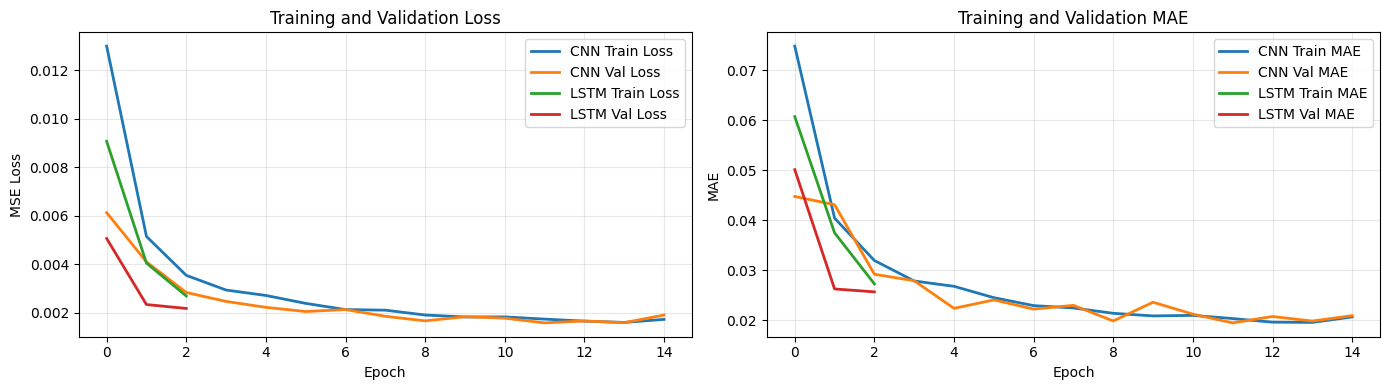

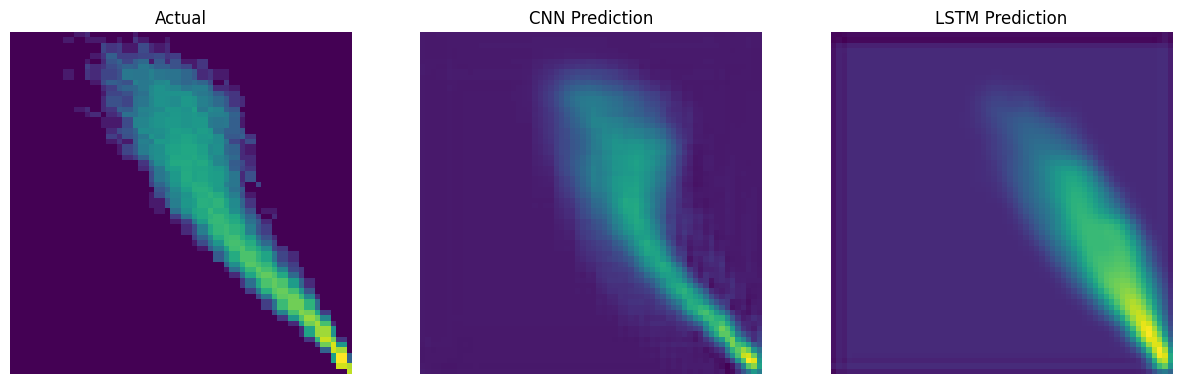

In [8]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_cnn.history['loss'], label='CNN Train Loss', linewidth=2)
axes[0].plot(history_cnn.history['val_loss'], label='CNN Val Loss', linewidth=2)
axes[0].plot(history_lstm.history['loss'], label='LSTM Train Loss', linewidth=2)
axes[0].plot(history_lstm.history['val_loss'], label='LSTM Val Loss', linewidth=2)
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn.history['mae'], label='CNN Train MAE', linewidth=2)
axes[1].plot(history_cnn.history['val_mae'], label='CNN Val MAE', linewidth=2)
axes[1].plot(history_lstm.history['mae'], label='LSTM Train MAE', linewidth=2)
axes[1].plot(history_lstm.history['val_mae'], label='LSTM Val MAE', linewidth=2)
axes[1].set_title('Training and Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualize predictions for one sample
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(y_test_denorm[0, :, :, 0], cmap='viridis')
axes[0].set_title('Actual')
axes[1].imshow(cnn_pred_denorm[0, :, :, 0], cmap='viridis')
axes[1].set_title('CNN Prediction')
axes[2].imshow(lstm_pred_denorm[0, :, :, 0], cmap='viridis')
axes[2].set_title('LSTM Prediction')
for ax in axes:
    ax.axis('off')

In [13]:
# Debug: Check prediction statistics
print("CNN prediction statistics:")
print(f"  Min: {cnn_pred_denorm.min():.6f}, Max: {cnn_pred_denorm.max():.6f}")
print(f"  Mean: {cnn_pred_denorm.mean():.6f}, Std: {cnn_pred_denorm.std():.6f}")
print(f"  Shape: {cnn_pred_denorm.shape}")

print("\nLSTM prediction statistics:")
print(f"  Min: {lstm_pred_denorm.min():.6f}, Max: {lstm_pred_denorm.max():.6f}")
print(f"  Mean: {lstm_pred_denorm.mean():.6f}, Std: {lstm_pred_denorm.std():.6f}")
print(f"  Shape: {lstm_pred_denorm.shape}")

print("\nActual target statistics:")
print(f"  Min: {y_test_denorm.min():.6f}, Max: {y_test_denorm.max():.6f}")
print(f"  Mean: {y_test_denorm.mean():.6f}, Std: {y_test_denorm.std():.6f}")
print(f"  Shape: {y_test_denorm.shape}")

CNN prediction statistics:
  Min: 0.000000, Max: 0.000007
  Mean: 0.000000, Std: 0.000000
  Shape: (200, 64, 64, 1)

LSTM prediction statistics:
  Min: 0.000008, Max: 0.104799
  Mean: 0.000147, Std: 0.001652
  Shape: (200, 64, 64, 1)

Actual target statistics:
  Min: 0.000000, Max: 8.648396
  Mean: 0.450524, Std: 0.923207
  Shape: (200, 64, 64, 1)


In [14]:
# Check training history
print("CNN final train/val loss:")
print(f"  Final train loss: {history_cnn.history['loss'][-1]:.6f}")
print(f"  Final val loss: {history_cnn.history['val_loss'][-1]:.6f}")

print("\nLSTM final train/val loss:")
print(f"  Final train loss: {history_lstm.history['loss'][-1]:.6f}")
print(f"  Final val loss: {history_lstm.history['val_loss'][-1]:.6f}")

# Check a sample raw prediction (before denormalization)
print("\nCNN raw prediction sample (first 5 values):")
print(f"  {cnn_pred[0, :5, :5, 0]}")

print("\nLSTM raw prediction sample (first 5 values):")
print(f"  {lstm_pred[0, :5, :5, 0]}")

print("\nTarget sample (first 5 values):")
print(f"  {y_test[0, :5, :5, 0]}")

CNN final train/val loss:
  Final train loss: 0.013671
  Final val loss: 0.013719

LSTM final train/val loss:
  Final train loss: 0.013670
  Final val loss: 0.013718

CNN raw prediction sample (first 5 values):
  [[1.9378164e-12 2.9841578e-25 6.2029431e-29 1.8934955e-36 1.2578651e-37]
 [6.4107664e-22 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [4.5920755e-26 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [4.2739778e-30 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]
 [3.4862833e-31 0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00]]

LSTM raw prediction sample (first 5 values):
  [[4.33067139e-03 4.22800076e-04 2.97542807e-04 2.82077322e-04
  2.80126813e-04]
 [2.01485775e-04 2.89919399e-06 1.62185620e-06 1.47258925e-06
  1.45291892e-06]
 [1.24958155e-04 1.53994051e-06 1.02522540e-06 9.68726681e-07
  9.62207764e-07]
 [1.15723546e-04 1.39931331e-06 9.65747176e-07 9.20067407e-07
  9.15164151e-07]
 [1.14503258e-04 1.38172140e-06 9.58688815e-07 9.1446

In [15]:
# Check target normalization
print("Normalized target statistics (y_test):")
print(f"  Min: {y_test.min():.6f}, Max: {y_test.max():.6f}")
print(f"  Mean: {y_test.mean():.6f}, Std: {y_test.std():.6f}")
print(f"  Percent zeros: {(y_test == 0).mean() * 100:.2f}%")

print("\nSample normalized target (non-zero region):")
# Find a sample with non-zero values
for i in range(len(y_test)):
    if y_test[i].max() > 0.1:
        print(f"  Sample {i} max: {y_test[i].max():.6f}")
        print(f"  First row: {y_test[i, 0, :10, 0]}")
        break
else:
    print("  No sample found with values > 0.1")

Normalized target statistics (y_test):
  Min: 0.000000, Max: 1.000000
  Mean: 0.052093, Std: 0.106749
  Percent zeros: 65.20%

Sample normalized target (non-zero region):
  Sample 0 max: 0.798848
  First row: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


# Summary

This notebook compares CNN and LSTM models for plume concentration forecasting.

- CNN uses convolutional layers on flattened temporal channels.
- LSTM uses ConvLSTM2D for spatio-temporal modeling.
- Both models are trained on the same dataset and evaluated with RMSE and R2.
- Training history and sample predictions are visualized for comparison.